## Notebook 2- Feature Relationship Analysis

### Section-1 Objective

This notebook investigates the statistical relationships between neighbourhood-level socioeconomic indicators and low-income prevalence within the City of Toronto.

The objective is to quantify the strength and direction of the relationships between the selected predictor variables and the target variable, **Low_Income_AfterTax_Pct**, prior to predictive modelling.

The analysis combines descriptive statistics, Pearson and Spearman correlation analysis, graphical exploration, and multicollinearity assessment to identify the socioeconomic indicators most strongly associated with neighbourhood vulnerability.

The findings from this notebook provide the statistical evidence required to answer **Research Question 1** and guide feature selection for the predictive modelling stage.

### Section 2. Project Input & Output

### Input

#### Dataset

- Machine learning-ready dataset produced in **Notebook 1**
- File: `neighbourhood_profiles_2016_ml_ready.csv`

The dataset contains standardized socioeconomic indicators for the City of Toronto and its 140 neighbourhoods. Each row represents one neighbourhood, while each column represents either a socioeconomic predictor variable or the target variable, **Low_Income_AfterTax_Pct**.

---

### Output

This notebook will produce:

- Descriptive statistical summary of all selected variables
- Pearson correlation analysis
- Spearman rank correlation analysis
- Correlation heatmap
- Ranked socioeconomic predictors based on their association with low-income prevalence
- Scatterplots of the strongest relationships
- Variance Inflation Factor (VIF) analysis for multicollinearity assessment
- Interpretation of statistically significant findings
- Evidence-based answer to **Research Question 1**

#### Dataset
- File: 'neighbourhood_profiles_2016_analysis_ready.csv'
         '02_Statistical_Analysis_Results.xlsx'

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.stats import pearsonr
from scipy.stats import spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
from pathlib import Path

project_root = Path.cwd().parents[1]

print(project_root)

c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project


### Section-3 Load Machine Learning Dataset

In [3]:
input_path = (
    project_root
    / "data"
    / "processed"
    / "neighbourhood_profiles_2016_ml_ready.csv")

df = pd.read_csv(input_path)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Dataset loaded from:\n{input_path}")

DATASET LOADED
Dataset loaded from:
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project\data\processed\neighbourhood_profiles_2016_ml_ready.csv


### Section 4- Dataset Verification

#### Purpose

Before conducting statistical analyses, the machine learning-ready dataset is inspected to verify its structure, dimensions, variable names, data types, and overall completeness.

This verification step confirms that the exported dataset from Notebook 1 has been loaded correctly and is suitable for subsequent statistical analyses. It also provides an opportunity to identify any unexpected structural issues prior to correlation analysis.

In [4]:
#Dataset Dimensions

print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

DATASET DIMENSIONS
Rows: 141
Columns: 14


In [5]:
# Dataset Preview

display(df.head())

,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree,No_Diploma,Immigrant_Population,Visible_Minority,Renters,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families,Low_Income_AfterTax_Pct
0,City of Toronto,2731571,64.70,59.30,8.20,534610,561090,1266005,1385855,525835,240780,36.60,152595,20.20
1,Agincourt North,29113,55.40,50.00,9.80,4380,7460,19995,26365,1720,2220,34.70,1650,21.30
2,Agincourt South-Malvern West,23757,59.00,53.20,9.80,4210,6090,15095,20155,2250,1795,38.20,1360,22.60
3,Alderwood,12054,66.50,62.40,6.10,1660,2960,3970,2490,950,540,21.70,670,8.20
4,Annex,30526,70.60,65.80,6.70,9135,4270,8270,7270,9870,2420,40.40,895,18.30


In [6]:
# Data Types
print("=" * 60)
print("DATA TYPES")
print("=" * 60)

display(df.dtypes)

DATA TYPES


Neighbourhood               object
Population                   int64
Participation_Rate         float64
Employment_Rate            float64
Unemployment_Rate          float64
Bachelors_Degree             int64
No_Diploma                   int64
Immigrant_Population         int64
Visible_Minority             int64
Renters                      int64
Core_Housing_Need            int64
Unaffordable_Housing       float64
Lone_Parent_Families         int64
Low_Income_AfterTax_Pct    float64
dtype: object

In [7]:
# Missing Values

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

display(df.isna().sum())

MISSING VALUES


Neighbourhood              0
Population                 0
Participation_Rate         0
Employment_Rate            0
Unemployment_Rate          0
Bachelors_Degree           0
No_Diploma                 0
Immigrant_Population       0
Visible_Minority           0
Renters                    0
Core_Housing_Need          0
Unaffordable_Housing       0
Lone_Parent_Families       0
Low_Income_AfterTax_Pct    0
dtype: int64

In [8]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Neighbourhood            141 non-null    object 
 1   Population               141 non-null    int64  
 2   Participation_Rate       141 non-null    float64
 3   Employment_Rate          141 non-null    float64
 4   Unemployment_Rate        141 non-null    float64
 5   Bachelors_Degree         141 non-null    int64  
 6   No_Diploma               141 non-null    int64  
 7   Immigrant_Population     141 non-null    int64  
 8   Visible_Minority         141 non-null    int64  
 9   Renters                  141 non-null    int64  
 10  Core_Housing_Need        141 non-null    int64  
 11  Unaffordable_Housing     141 non-null    float64
 12  Lone_Parent_Families     141 non-null    int64  
 13  Low_Income_AfterTax_Pct  141 non-null    float64
dtypes: float64(5), int64(8), o

### Interpretation

The inspection confirms that the machine learning-ready dataset was successfully loaded and retains the structure established in Notebook 1.

The dataset contains one observation for the City of Toronto and each of the 140 neighbourhoods, with standardized socioeconomic predictor variables and a single target variable representing neighbourhood-level low-income prevalence.

All variables exhibit the expected data types, and no missing values were detected. These results confirm that the dataset is complete and suitable for the statistical analyses presented in the following sections.

### Section-5. Feature Normalization

#### Purpose

Several socioeconomic indicators contained in the machine learning-ready dataset represent absolute population counts rather than proportions.

Because neighbourhoods vary substantially in population size, direct comparison of count-based indicators may produce misleading statistical relationships driven primarily by neighbourhood size rather than socioeconomic characteristics.

To improve comparability across neighbourhoods, selected count-based indicators are converted to population-based percentages using the total neighbourhood population as the denominator.

This feature engineering step allows the subsequent statistical analyses to quantify relationships between socioeconomic characteristics and neighbourhood-level low-income prevalence while minimizing the influence of population size.

In [9]:
count_variables = [
    "Bachelors_Degree",
    "No_Diploma",
    "Immigrant_Population",
    "Visible_Minority",
    "Renters",
    "Lone_Parent_Families"]

for column in count_variables:
    df[column + "_Pct"] = (
        df[column] / df["Population"]
    ) * 100

print("=" * 60)
print("FEATURE NORMALIZATION COMPLETE")
print("=" * 60)

display(
    df[
        [
            "Neighbourhood",
            "Population",
            "Bachelors_Degree",
            "Bachelors_Degree_Pct",
            "Immigrant_Population",
            "Immigrant_Population_Pct"
        ]    ].head())

FEATURE NORMALIZATION COMPLETE


,Neighbourhood,Population,Bachelors_Degree,Bachelors_Degree_Pct,Immigrant_Population,Immigrant_Population_Pct
0,City of Toronto,2731571,534610,19.57,1266005,46.35
1,Agincourt North,29113,4380,15.04,19995,68.68
2,Agincourt South-Malvern West,23757,4210,17.72,15095,63.54
3,Alderwood,12054,1660,13.77,3970,32.94
4,Annex,30526,9135,29.93,8270,27.09


### Interpretation

The selected count-based socioeconomic indicators were successfully converted to population-based percentages.

Using normalized indicators reduces the influence of neighbourhood population size and provides a more appropriate basis for comparing socioeconomic characteristics across Toronto neighbourhoods.

These normalized variables will be used throughout the remainder of the statistical analyses to quantify the relationships between neighbourhood characteristics and low-income prevalence.

### Section-6.  Descriptive Statistics

#### Purpose

Before quantifying the relationships between socioeconomic indicators and neighbourhood-level low-income prevalence, descriptive statistics are examined to summarize the characteristics of each variable.

This preliminary analysis provides measures of central tendency, variability, and distribution, allowing an initial assessment of the socioeconomic conditions represented within the dataset.

The descriptive statistics also provide context for the subsequent Pearson and Spearman correlation analyses by identifying the range and variability of each predictor and the target variable.

In [10]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe().T.round(2))

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Population,141.00,38745.69,228615.35,6577.00,12054.00,16775.00,23925.00,2731571.00
Participation_Rate,141.00,64.55,6.09,52.20,59.90,63.60,69.10,86.60
Employment_Rate,141.00,59.27,6.49,47.30,54.70,58.60,64.30,82.70
Unemployment_Rate,141.00,8.30,1.89,4.50,6.90,8.20,9.60,14.60
Bachelors_Degree,141.00,7583.48,44803.64,445.00,2060.00,3265.00,4400.00,534610.00
No_Diploma,141.00,7958.55,46969.84,1190.00,2380.00,3385.00,5205.00,561090.00
Immigrant_Population,141.00,17957.52,106032.04,1795.00,4645.00,7520.00,11425.00,1266005.00
Visible_Minority,141.00,19657.59,116175.10,1100.00,3635.00,7270.00,12700.00,1385855.00
Renters,141.00,7458.37,44069.12,280.00,1955.00,3235.00,4350.00,525835.00
Core_Housing_Need,141.00,3415.60,20157.26,115.00,970.00,1435.00,2325.00,240780.00


### Interpretation

The descriptive statistics provide an overview of the socioeconomic characteristics of the City of Toronto and its neighbourhoods.

All variables contain 141 complete observations, confirming that the dataset is suitable for statistical analysis. The predictor variables exhibit substantial variability, indicating meaningful differences in population size, labour market conditions, educational attainment, housing characteristics, and demographic composition across neighbourhoods.

The target variable, **Low_Income_AfterTax_Pct**, ranges from **4.50%** to **45.50%**, with an average neighbourhood-level low-income prevalence of **19.52%**. This variation suggests that socioeconomic vulnerability differs considerably across Toronto neighbourhoods, supporting the need for further investigation into the relationships between the selected predictor variables and neighbourhood-level low-income prevalence.

The descriptive statistics provide the necessary context for the correlation analyses presented in the following section.

### Section-7. Correlation Analysis

#### Purpose

The objective of this section is to quantify the relationships between the selected socioeconomic indicators and neighbourhood-level low-income prevalence.

Pearson correlation analysis measures the strength and direction of linear relationships between the predictor variables and the target variable, **Low_Income_AfterTax_Pct**.

To improve comparability across neighbourhoods, the normalized percentage indicators generated in the previous section are used in place of their corresponding count variables wherever appropriate.

The resulting correlation coefficients provide quantitative evidence for identifying the socioeconomic indicators most strongly associated with neighbourhood-level low-income prevalence.

In [11]:
# Variables for Correlation Analysis

correlation_df = df[
    [
        "Population",
        "Participation_Rate",
        "Employment_Rate",
        "Unemployment_Rate",
        "Bachelors_Degree_Pct",
        "No_Diploma_Pct",
        "Immigrant_Population_Pct",
        "Visible_Minority_Pct",
        "Renters_Pct",
        "Core_Housing_Need",
        "Unaffordable_Housing",
        "Lone_Parent_Families_Pct",
        "Low_Income_AfterTax_Pct"
    ]]

#### 7.1 Pearson Correlation Analysis

Pearson correlation coefficients are calculated to measure the strength and direction of the linear relationship between each socioeconomic predictor and neighbourhood-level low-income prevalence.

Correlation coefficients range from **-1** to **+1**:

- **+1** indicates a perfect positive relationship.
- **-1** indicates a perfect negative relationship.
- **0** indicates no linear relationship.

Variables with larger absolute correlation coefficients are considered more strongly associated with the target variable.

In [12]:
# Pearson Correlation Matrix
pearson_corr = correlation_df.corr(method="pearson")

print("=" * 60)
print("PEARSON CORRELATION MATRIX")
print("=" * 60)

display(pearson_corr.round(3))

PEARSON CORRELATION MATRIX


,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct,Low_Income_AfterTax_Pct
Population,1.00,0.00,-0.00,0.00,0.01,0.01,0.03,0.03,0.01,1.00,0.03,-0.00,0.01
Participation_Rate,0.00,1.00,0.99,-0.67,0.62,-0.66,-0.72,-0.66,0.45,-0.00,-0.06,-0.56,-0.39
Employment_Rate,-0.00,0.99,1.00,-0.77,0.65,-0.69,-0.75,-0.71,0.39,-0.01,-0.13,-0.60,-0.47
Unemployment_Rate,0.00,-0.67,-0.77,1.00,-0.61,0.61,0.69,0.78,0.00,0.01,0.40,0.62,0.73
Bachelors_Degree_Pct,0.01,0.62,0.65,-0.61,1.00,-0.83,-0.56,-0.50,0.32,-0.00,0.06,-0.88,-0.32
No_Diploma_Pct,0.01,-0.66,-0.69,0.61,-0.83,1.00,0.69,0.66,-0.32,0.02,0.10,0.72,0.37
Immigrant_Population_Pct,0.03,-0.72,-0.75,0.69,-0.56,0.69,1.00,0.89,-0.20,0.04,0.43,0.56,0.56
Visible_Minority_Pct,0.03,-0.66,-0.71,0.78,-0.50,0.66,0.89,1.00,-0.14,0.04,0.45,0.53,0.66
Renters_Pct,0.01,0.45,0.39,0.00,0.32,-0.32,-0.20,-0.14,1.00,0.02,0.64,-0.15,0.47
Core_Housing_Need,1.00,-0.00,-0.01,0.01,-0.00,0.02,0.04,0.04,0.02,1.00,0.05,0.01,0.04


In [13]:
# Pearson Correlation with Target Variable
pearson_target = (
    pearson_corr["Low_Income_AfterTax_Pct"]
    .drop("Low_Income_AfterTax_Pct"))

pearson_target = pearson_target.reindex(
    pearson_target.abs().sort_values(ascending=False).index)

display(
    pearson_target.to_frame(
        name="Pearson Correlation"
    ).round(3))

,Pearson Correlation
Unaffordable_Housing,0.78
Unemployment_Rate,0.73
Visible_Minority_Pct,0.66
Immigrant_Population_Pct,0.56
Employment_Rate,-0.47
Renters_Pct,0.47
Lone_Parent_Families_Pct,0.43
Participation_Rate,-0.39
No_Diploma_Pct,0.37
Bachelors_Degree_Pct,-0.32


### 7.2. Statistical Significance of Pearson Correlations

To complement the Pearson correlation coefficients, statistical significance is assessed using two-tailed Pearson correlation tests.

For each predictor variable, the Pearson correlation coefficient (r) and associated p-value are calculated relative to the target variable, **Low_Income_AfterTax_Pct**.

This analysis identifies which relationships are statistically significant and therefore provide stronger evidence of association.

In [14]:
# Pearson Correlation Significance

from scipy.stats import pearsonr

target = "Low_Income_AfterTax_Pct"

results = []

for column in correlation_df.columns:
    if column == target:
        continue

    r, p = pearsonr(correlation_df[column], correlation_df[target])

    results.append({
        "Variable": column,
        "Pearson_r": r,
        "P_value": p    })

pearson_results = (
    pd.DataFrame(results)
      .sort_values(by="Pearson_r", key=lambda s: s.abs(), ascending=False))

display(pearson_results.round(4))

,Variable,Pearson_r,P_value
10,Unaffordable_Housing,0.78,0.00
3,Unemployment_Rate,0.73,0.00
7,Visible_Minority_Pct,0.66,0.00
6,Immigrant_Population_Pct,0.56,0.00
2,Employment_Rate,-0.47,0.00
8,Renters_Pct,0.47,0.00
11,Lone_Parent_Families_Pct,0.43,0.00
1,Participation_Rate,-0.39,0.00
5,No_Diploma_Pct,0.37,0.00
4,Bachelors_Degree_Pct,-0.32,0.00


In [15]:
pearson_results["Significance"] = pearson_results["P_value"].apply(
    lambda p: "p < 0.001" if p < 0.001 else f"p = {p:.3f}")

display(
    pearson_results[
        ["Variable", "Pearson_r", "Significance"]
    ].round(3))

,Variable,Pearson_r,Significance
10,Unaffordable_Housing,0.78,p < 0.001
3,Unemployment_Rate,0.73,p < 0.001
7,Visible_Minority_Pct,0.66,p < 0.001
6,Immigrant_Population_Pct,0.56,p < 0.001
2,Employment_Rate,-0.47,p < 0.001
8,Renters_Pct,0.47,p < 0.001
11,Lone_Parent_Families_Pct,0.43,p < 0.001
1,Participation_Rate,-0.39,p < 0.001
5,No_Diploma_Pct,0.37,p < 0.001
4,Bachelors_Degree_Pct,-0.32,p < 0.001


#### Interpretation

The Pearson correlation analysis quantified the linear relationships between the selected socioeconomic indicators and neighbourhood-level low-income prevalence.

The Pearson correlation analysis identified the strongest positive linear associations between neighbourhood-level low-income prevalence and Unaffordable_Housing (r = 0.78), Unemployment_Rate (r = 0.73), Visible_Minority_Pct (r = 0.66), and Immigrant_Population_Pct (r = 0.**Unaffordable_Housing** (*r* = 0.78), **Unemployment_Rate** (*r* = 0.73), **Visible_Minority_Pct** (*r* = 0.66), and **Immigrant_Population_Pct** (*r* = 0.56), indicating that neighbourhoods with higher housing unaffordability, unemployment, visible minority populations, and immigrant populations tended to exhibit higher levels of low-income prevalence.

Conversely, **Employment_Rate** (*r* = −0.47), **Participation_Rate** (*r* = −0.39), and **Bachelors_Degree_Pct** (*r* = −0.32) demonstrated negative associations with neighbourhood-level low-income prevalence, suggesting that neighbourhoods with stronger labour market participation and higher educational attainment generally experienced lower levels of socioeconomic vulnerability.

All predictor variables, with the exception of **Population**, were statistically significant (*p* < 0.001), providing strong evidence that these socioeconomic indicators are associated with neighbourhood-level low-income prevalence.

These findings provide the first quantitative evidence addressing **Research Question 1** and establish the foundation for further assessment using Spearman rank correlation.

#### 7.3. Spearman Rank Correlation

### Purpose

While Pearson correlation measures linear relationships, Spearman rank correlation evaluates monotonic relationships between variables and is less sensitive to non-normality and outliers.

Spearman correlation is included to determine whether the socioeconomic indicators identified through Pearson correlation remain consistently associated with neighbourhood-level low-income prevalence when a non-parametric correlation measure is applied.

Agreement between Pearson and Spearman correlation analyses provides stronger statistical evidence regarding the socioeconomic indicators most strongly associated with neighbourhood-level low-income prevalence.

In [16]:
# Spearman Correlation Matrix

spearman_corr = correlation_df.corr(method="spearman")

print("=" * 60)
print("SPEARMAN CORRELATION MATRIX")
print("=" * 60)

display(spearman_corr.round(3))

SPEARMAN CORRELATION MATRIX


,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct,Low_Income_AfterTax_Pct
Population,1.00,-0.14,-0.15,0.23,0.00,0.17,0.35,0.42,0.05,0.84,0.33,0.05,0.29
Participation_Rate,-0.14,1.00,0.99,-0.70,0.57,-0.65,-0.75,-0.68,0.40,-0.19,-0.09,-0.56,-0.45
Employment_Rate,-0.15,0.99,1.00,-0.78,0.61,-0.68,-0.78,-0.73,0.36,-0.24,-0.14,-0.61,-0.52
Unemployment_Rate,0.23,-0.70,-0.78,1.00,-0.62,0.65,0.73,0.80,-0.02,0.45,0.39,0.66,0.76
Bachelors_Degree_Pct,0.00,0.57,0.61,-0.62,1.00,-0.84,-0.57,-0.54,0.25,-0.21,0.06,-0.90,-0.38
No_Diploma_Pct,0.17,-0.65,-0.68,0.65,-0.84,1.00,0.68,0.67,-0.34,0.28,0.05,0.77,0.40
Immigrant_Population_Pct,0.35,-0.75,-0.78,0.73,-0.57,0.68,1.00,0.89,-0.19,0.48,0.42,0.59,0.61
Visible_Minority_Pct,0.42,-0.68,-0.73,0.80,-0.54,0.67,0.89,1.00,-0.12,0.55,0.46,0.56,0.72
Renters_Pct,0.05,0.40,0.36,-0.02,0.25,-0.34,-0.19,-0.12,1.00,0.38,0.62,-0.13,0.40
Core_Housing_Need,0.84,-0.19,-0.24,0.45,-0.21,0.28,0.48,0.55,0.38,1.00,0.61,0.30,0.65


In [17]:
# Spearman Correlation with Target Variable

spearman_target = (
    spearman_corr["Low_Income_AfterTax_Pct"]
    .drop("Low_Income_AfterTax_Pct"))

spearman_target = spearman_target.reindex(
    spearman_target.abs().sort_values(ascending=False).index)

display(
    spearman_target.to_frame(
        name="Spearman Correlation"
    ).round(3))

,Spearman Correlation
Unemployment_Rate,0.76
Unaffordable_Housing,0.74
Visible_Minority_Pct,0.72
Core_Housing_Need,0.65
Immigrant_Population_Pct,0.61
Employment_Rate,-0.52
Lone_Parent_Families_Pct,0.50
Participation_Rate,-0.45
No_Diploma_Pct,0.40
Renters_Pct,0.40


In [18]:
# Spearman Correlation Significance

from scipy.stats import spearmanr

results = []

target = "Low_Income_AfterTax_Pct"

for column in correlation_df.columns:

    if column == target:
        continue

    rho, p = spearmanr(
        correlation_df[column],
        correlation_df[target]    )

    results.append({
        "Variable": column,
        "Spearman_rho": rho,
        "P_value": p    })

spearman_results = (
    pd.DataFrame(results)
      .sort_values(
          by="Spearman_rho",
          key=lambda s: s.abs(),
          ascending=False      ))

spearman_results["Significance"] = (
    spearman_results["P_value"]
    .apply(lambda p: "p < 0.001" if p < 0.001 else f"p = {p:.3f}"))

display(
    spearman_results[
        ["Variable", "Spearman_rho", "Significance"]    ].round(3))

,Variable,Spearman_rho,Significance
3,Unemployment_Rate,0.76,p < 0.001
10,Unaffordable_Housing,0.74,p < 0.001
7,Visible_Minority_Pct,0.72,p < 0.001
9,Core_Housing_Need,0.65,p < 0.001
6,Immigrant_Population_Pct,0.61,p < 0.001
2,Employment_Rate,-0.52,p < 0.001
11,Lone_Parent_Families_Pct,0.50,p < 0.001
1,Participation_Rate,-0.45,p < 0.001
5,No_Diploma_Pct,0.40,p < 0.001
8,Renters_Pct,0.40,p < 0.001


In [19]:
# Pearson vs Spearman Comparison

comparison = (
    pearson_results[["Variable", "Pearson_r"]]
    .merge(
        spearman_results[["Variable", "Spearman_rho"]],
        on="Variable"    ))

comparison["Absolute_Difference"] = (
    comparison["Pearson_r"] - comparison["Spearman_rho"]
).abs()

comparison["Consistency"] = comparison["Absolute_Difference"].apply(
    lambda x: "High" if x < 0.10 else "Moderate")

comparison = comparison.sort_values(
    by="Pearson_r",
    key=lambda s: s.abs(),
    ascending=False)

display(comparison.round(3))

,Variable,Pearson_r,Spearman_rho,Absolute_Difference,Consistency
0,Unaffordable_Housing,0.78,0.74,0.03,High
1,Unemployment_Rate,0.73,0.76,0.03,High
2,Visible_Minority_Pct,0.66,0.72,0.06,High
3,Immigrant_Population_Pct,0.56,0.61,0.05,High
4,Employment_Rate,-0.47,-0.52,0.05,High
5,Renters_Pct,0.47,0.40,0.07,High
6,Lone_Parent_Families_Pct,0.43,0.50,0.07,High
7,Participation_Rate,-0.39,-0.45,0.06,High
8,No_Diploma_Pct,0.37,0.40,0.04,High
9,Bachelors_Degree_Pct,-0.32,-0.38,0.06,High


### Interpretation

The Pearson and Spearman correlation analyses produced highly consistent results for the majority of socioeconomic indicators.

Differences between the Pearson and Spearman correlation coefficients were generally small (less than 0.10), indicating that the identified relationships were robust and not dependent on the assumption of linearity.

Across both correlation methods, **Unaffordable_Housing**, **Unemployment_Rate**, **Visible_Minority_Pct**, and **Immigrant_Population_Pct** consistently emerged as the strongest positive indicators of neighbourhood-level low-income prevalence. Conversely, **Employment_Rate**, **Participation_Rate**, and **Bachelors_Degree_Pct** consistently demonstrated negative associations.

The larger difference observed for **Core_Housing_Need** suggests that its relationship with neighbourhood-level low-income prevalence may be non-linear or influenced by the way the variable is represented within the dataset. Consequently, this variable should be interpreted with caution.

Overall, the agreement between Pearson and Spearman correlation analyses provides strong statistical evidence identifying the socioeconomic indicators most strongly associated with neighbourhood-level low-income prevalence, thereby directly addressing **Research Question 1**.

### 8. Correlation Heatmap

#### Purpose

To complement the numerical correlation analyses, a correlation heatmap is generated to visualize the strength and direction of the relationships between the selected socioeconomic indicators.

The heatmap provides an intuitive overview of the correlation structure and assists in identifying groups of variables that exhibit similar relationships with neighbourhood-level low-income prevalence.

This visualization complements the Pearson and Spearman correlation analyses presented in the previous section.

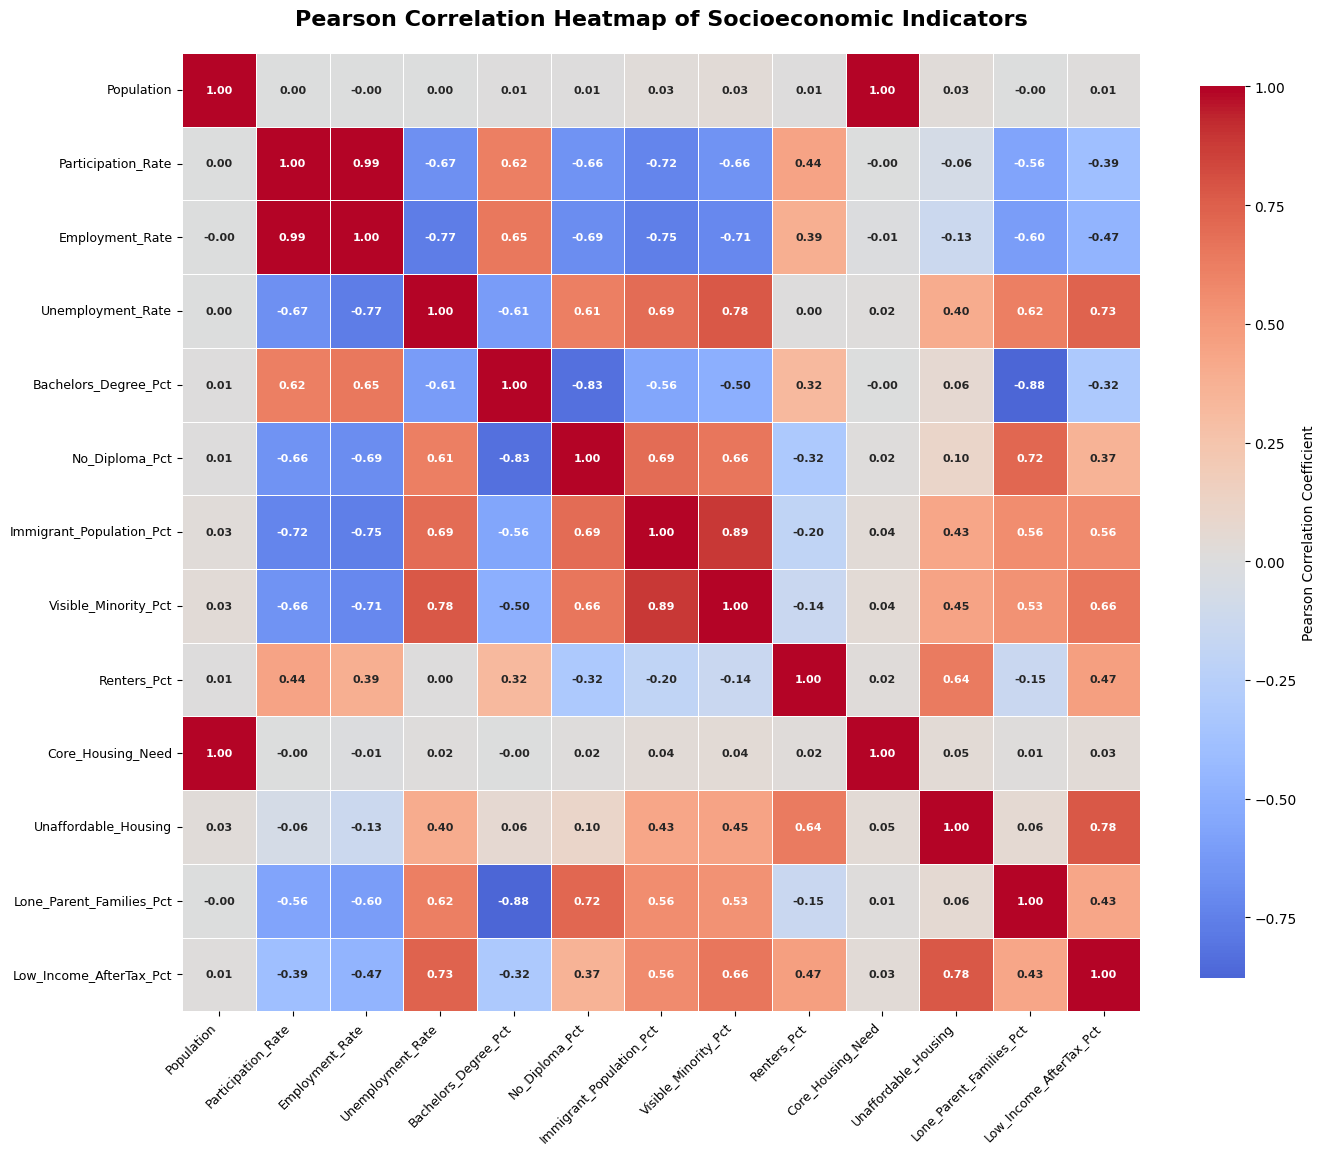

In [20]:
# Pearson Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))

sns.heatmap(
    pearson_corr,
    annot=True,                 # Show correlation coefficients
    fmt=".2f",                  # Display two decimal places
    cmap="coolwarm",            # Blue = negative, Red = positive
    center=0,                   # Center color scale at zero
    linewidths=0.6,
    linecolor="white",
    square=True,
    annot_kws={
        "size": 8,
        "weight": "bold"    },
    cbar_kws={
        "label": "Pearson Correlation Coefficient",
        "shrink": 0.85    })

plt.title(
    "Pearson Correlation Heatmap of Socioeconomic Indicators",
    fontsize=16,
    fontweight="bold",
    pad=20)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

plt.show()

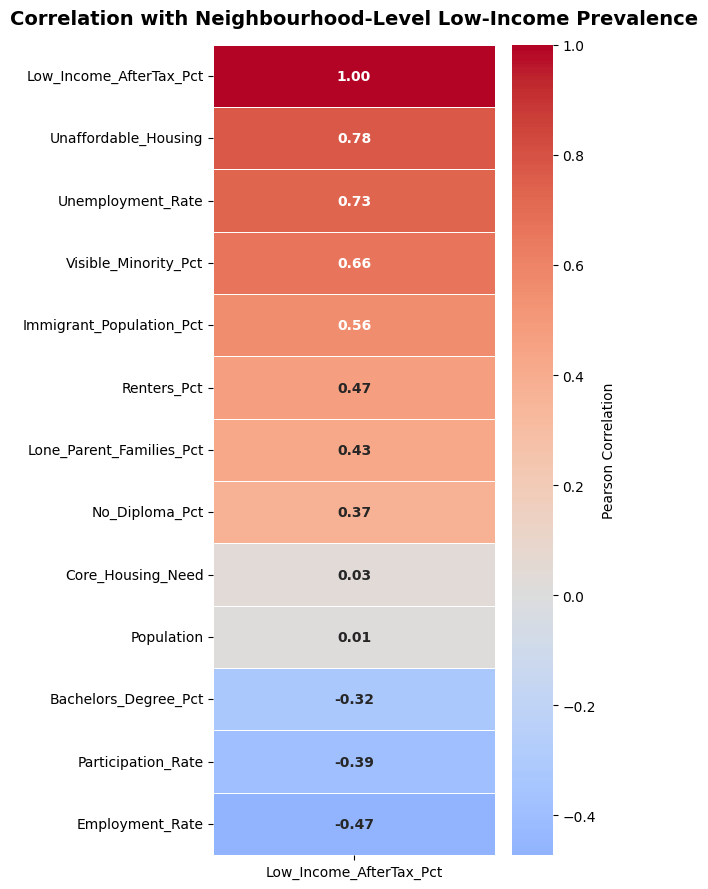

In [21]:
# Pearson Correlation with Target Variable

plt.figure(figsize=(6, 9))

target_corr = pearson_corr[["Low_Income_AfterTax_Pct"]].sort_values(
    by="Low_Income_AfterTax_Pct",
    ascending=False)

sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    annot_kws={
        "size": 10,
        "weight": "bold"
    },
    cbar_kws={
        "label": "Pearson Correlation"    })

plt.title(
    "Correlation with Neighbourhood-Level Low-Income Prevalence",
    fontsize=14,
    fontweight="bold",
    pad=15)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Interpretation

The annotated Pearson correlation heatmap visually summarizes the strength and direction of the linear relationships among the selected socioeconomic indicators.

The visualization confirms the numerical findings obtained from the Pearson correlation analysis. Strong positive correlations between **Low_Income_AfterTax_Pct** and **Unaffordable_Housing**, **Unemployment_Rate**, **Visible_Minority_Pct**, and **Immigrant_Population_Pct** are clearly observed. Conversely, **Employment_Rate**, **Participation_Rate**, and **Bachelors_Degree_Pct** exhibit negative correlations with neighbourhood-level low-income prevalence.

The heatmap also reveals several strong correlations among predictor variables themselves, indicating the possible presence of multicollinearity. This observation motivates the subsequent Variance Inflation Factor (VIF) analysis.

### Summary of Correlation Analyses

The Pearson and Spearman correlation analyses produced highly consistent rankings of the selected socioeconomic indicators. The small differences observed between the two correlation coefficients indicate that the identified relationships are robust and not sensitive to the choice of correlation method.

Across both analyses, **Unaffordable_Housing**, **Unemployment_Rate**, **Visible_Minority_Pct**, and **Immigrant_Population_Pct** consistently emerged as the strongest positive predictors of neighbourhood-level low-income prevalence. Similarly, **Employment_Rate**, **Participation_Rate**, and **Bachelors_Degree_Pct** consistently demonstrated negative associations.

The agreement between the two correlation methods provides strong statistical evidence that these socioeconomic indicators are meaningfully associated with neighbourhood vulnerability and low-income prevalence, thereby directly addressing Research Question 1.

### 9. Multicollinearity Assessment (Variance Inflation Factor)

### Purpose

The previous correlation analyses identified socioeconomic indicators that are significantly associated with neighbourhood-level low-income prevalence. However, predictor variables may also be highly correlated with one another, resulting in multicollinearity.

Multicollinearity can reduce the stability and interpretability of predictive models by introducing redundant information.

To assess the degree of multicollinearity among the selected predictor variables, the Variance Inflation Factor (VIF) is calculated for each predictor. Variables with high VIF values indicate potential redundancy and should be interpreted carefully during subsequent predictive modelling.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = correlation_df.drop(columns=[
    "Population",
    "Low_Income_AfterTax_Pct"])

X = add_constant(X)

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])    ]})

vif = (
    vif[vif["Variable"] != "const"]
    .sort_values(by="VIF", ascending=False))

display(vif.round(2))

,Variable,VIF
2,Employment_Rate,3229.72
1,Participation_Rate,2443.51
3,Unemployment_Rate,117.55
4,Bachelors_Degree_Pct,8.95
7,Visible_Minority_Pct,7.98
6,Immigrant_Population_Pct,7.27
11,Lone_Parent_Families_Pct,5.27
5,No_Diploma_Pct,5.22
10,Unaffordable_Housing,4.44
8,Renters_Pct,4.01


In [23]:
# VIF Interpretation

def interpret_vif(vif):
    if vif < 5:
        return "Low"
    elif vif < 10:
        return "Moderate"
    elif vif < 20:
        return "High"
    else:
        return "Very High"

vif["Interpretation"] = vif["VIF"].apply(interpret_vif)

display(vif.round(2))

,Variable,VIF,Interpretation
2,Employment_Rate,3229.72,Very High
1,Participation_Rate,2443.51,Very High
3,Unemployment_Rate,117.55,Very High
4,Bachelors_Degree_Pct,8.95,Moderate
7,Visible_Minority_Pct,7.98,Moderate
6,Immigrant_Population_Pct,7.27,Moderate
11,Lone_Parent_Families_Pct,5.27,Moderate
5,No_Diploma_Pct,5.22,Moderate
10,Unaffordable_Housing,4.44,Low
8,Renters_Pct,4.01,Low


### 10. Research Question 1 Summary

### Research Question 1

**Which socioeconomic variables are the strongest predictors of neighbourhood-level low-income prevalence in Toronto?**

### Quantitative Findings

The statistical analyses consistently identified several socioeconomic indicators as the strongest predictors of neighbourhood-level low-income prevalence.

Using Pearson correlation analysis, the strongest positive linear associations with **Low_Income_AfterTax_Pct** were:

| Predictor | Pearson (r) | Spearman (ρ) |
|-----------|------------:|-------------:|
| Unaffordable_Housing | **0.78** | **0.74** |
| Unemployment_Rate | **0.73** | **0.76** |
| Visible_Minority_Pct | **0.66** | **0.72** |
| Immigrant_Population_Pct | **0.56** | **0.61** |

The strongest negative associations were:

| Predictor | Pearson (r) | Spearman (ρ) |
|-----------|------------:|-------------:|
| Employment_Rate | **−0.47** | **−0.52** |
| Participation_Rate | **−0.39** | **−0.45** |
| Bachelors_Degree_Pct | **−0.32** | **−0.38** |

All reported correlations were statistically significant (**p < 0.001**).

The comparison between Pearson and Spearman correlation coefficients showed only small differences (generally less than **0.10**), indicating that the observed relationships were robust across both parametric and non-parametric correlation methods.

The VIF analysis identified substantial multicollinearity among **Employment_Rate**, **Participation_Rate**, and **Unemployment_Rate**, which is expected because these variables represent closely related labour market indicators. All remaining predictor variables demonstrated acceptable levels of multicollinearity for subsequent modelling.

Overall, the quantitative analyses indicate that **housing affordability**, **labour market conditions**, **visible minority population**, and **immigrant population** are the socioeconomic domains most strongly associated with neighbourhood-level low-income prevalence across Toronto neighbourhoods.

### 11. Conclusion

#### Summary

This notebook investigated the statistical relationships between selected socioeconomic indicators and neighbourhood-level low-income prevalence using the machine learning-ready dataset developed in Notebook 1.

A comprehensive statistical analysis was conducted using descriptive statistics, Pearson correlation, Spearman rank correlation, statistical significance testing, correlation heatmaps, and Variance Inflation Factor (VIF) analysis.

The quantitative analyses consistently identified **Unaffordable_Housing** as the strongest predictor of neighbourhood-level low-income prevalence, with a Pearson correlation of **0.78** and a Spearman correlation of **0.74**. Strong positive associations were also observed for **Unemployment_Rate** (Pearson **0.73**, Spearman **0.76**), **Visible_Minority_Pct** (Pearson **0.66**, Spearman **0.72**), and **Immigrant_Population_Pct** (Pearson **0.56**, Spearman **0.61**). Conversely, **Employment_Rate** (Pearson **−0.47**, Spearman **−0.52**), **Participation_Rate** (Pearson **−0.39**, Spearman **−0.45**), and **Bachelors_Degree_Pct** (Pearson **−0.32**, Spearman **−0.38**) demonstrated consistent negative relationships with neighbourhood-level low-income prevalence.

All reported correlations were statistically significant (**p < 0.001**), and the close agreement between Pearson and Spearman coefficients confirmed that the identified relationships were robust across both parametric and non-parametric correlation methods.

The VIF analysis identified substantial multicollinearity among the labour market indicators (**Employment_Rate**, **Participation_Rate**, and **Unemployment_Rate**), reflecting their close conceptual relationship. The remaining predictor variables exhibited low to moderate multicollinearity and remain suitable for subsequent predictive modelling.

Overall, the analyses provide quantitative evidence that housing affordability, labour market conditions, demographic composition, and educational attainment are the socioeconomic domains most strongly associated with neighbourhood-level low-income prevalence in Toronto. These findings directly address **Research Question 1** and establish a statistically supported foundation for the dimensionality reduction and predictive modelling analyses presented in the subsequent notebooks.

#### Next Steps

The next notebook will build upon the statistically validated predictor variables identified in this analysis.

Principal Component Analysis (PCA) will be applied to reduce redundancy among correlated socioeconomic indicators and identify the principal dimensions underlying neighbourhood vulnerability. The reduced feature space will then support neighbourhood vulnerability assessment through clustering techniques, providing additional insight into the socioeconomic profiles of Toronto neighbourhoods prior to predictive modelling.

### 12. Export Statistical Analysis Results

#### Purpose

Following the completion of the statistical analyses, the key analytical outputs are exported to a consolidated Excel workbook to support reproducibility, documentation, and future modelling activities.

The exported workbook provides a structured summary of the quantitative findings generated throughout this notebook, including descriptive statistics, correlation analyses, comparison of correlation methods, and multicollinearity assessment.

The workbook serves as a supplementary analytical report that documents the statistical evidence used to answer **Research Question 1** and provides a reference for subsequent notebooks in this capstone project.

#### Output

The following worksheets are exported to a single Excel workbook:

- **RQ1 Summary** – Quantitative summary answering Research Question 1.
- **Descriptive Statistics** – Summary statistics for all selected variables.
- **Pearson Correlation** – Pearson correlation coefficients, significance levels, and statistical results.
- **Spearman Correlation** – Spearman rank correlation coefficients, significance levels, and statistical results.
- **Correlation Comparison** – Comparison between Pearson and Spearman correlation coefficients.
- **VIF Results** – Variance Inflation Factor (VIF) values and multicollinearity assessment.

The workbook is saved in the **reports** directory as:

`02_Statistical_Analysis_Results.xlsx`

In [24]:
rq1_summary = pd.DataFrame({
    "Research Question": [
        "Which socioeconomic variables are the strongest predictors of neighbourhood-level low-income prevalence?"
    ],
    "Strongest Positive Predictor": [
        "Unaffordable_Housing (Pearson r = 0.78, Spearman ρ = 0.74)"
    ],
    "Second Strongest Predictor": [
        "Unemployment_Rate (Pearson r = 0.73, Spearman ρ = 0.76)"
    ],
    "Third Strongest Predictor": [
        "Visible_Minority_Pct (Pearson r = 0.66, Spearman ρ = 0.72)"
    ],
    "All Significant": [
        "Yes (p < 0.001)"    ]})

In [25]:
# Export Statistical Analysis Results

from pathlib import Path
import pandas as pd

# Create Reports folder
reports_folder = project_root / "reports"
reports_folder.mkdir(exist_ok=True)

# Excel filename
excel_path = reports_folder / "02_Statistical_Analysis_Results.xlsx"

# Export workbook
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    rq1_summary.to_excel(
        writer,
        sheet_name="RQ1_Summary",
        index=False    )

    df.describe().T.round(3).to_excel(
        writer,
        sheet_name="Descriptive_Statistics"    )

    pearson_results.round(3).to_excel(
        writer,
        sheet_name="Pearson_Correlation",
        index=False    )

    spearman_results.round(3).to_excel(
        writer,
        sheet_name="Spearman_Correlation",
        index=False    )

    comparison.round(3).to_excel(
        writer,
        sheet_name="Comparison",
        index=False    )

    vif.round(3).to_excel(
        writer,
        sheet_name="VIF_Results",
        index=False    )

print("="*60)
print("EXPORT COMPLETED")
print("="*60)
print(excel_path)

EXPORT COMPLETED
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project\reports\02_Statistical_Analysis_Results.xlsx


In [26]:
analysis_ready = df.copy()

analysis_ready.to_csv(
    project_root /
    "data" /
    "processed" /
    "neighbourhood_profiles_2016_analysis_ready.csv",
    index=False)

print("Analysis-ready dataset exported successfully.")

Analysis-ready dataset exported successfully.
